# Zero-Noise Extrapolation (ZNE) with Indirect-Control System
---

This experiment is:

- Qubit: 7, layer: 30
- System has noise-free time evolution.
- Target observable: Transverse field Ising Hamiltonian.
- Ansatz time-evolution: Noise-free time-evolution with XY, Ising, and Heisenberg Hamiltonians.
- Time-constraint: True

## (1) Import and setup

In [1]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import os
import sys
import json
import textwrap
import importlib
from datetime import datetime
from string import Template
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union, Optional
from pprint import pprint

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
from tabulate import tabulate
from IPython.display import display

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[2] / "src"))

from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped

In [2]:
# Set the default font to be LaTeX compliant.
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Computer Modern Roman"
plt.rcParams["text.usetex"] = True

# Set a global font size.
font_size = 11
plt.rcParams["font.size"] = font_size
plt.rcParams["axes.labelsize"] = font_size
plt.rcParams["xtick.labelsize"] = font_size
plt.rcParams["ytick.labelsize"] = font_size
plt.rcParams["legend.fontsize"] = 10

In [3]:
BASE_PATH = "data"

ZNE_MODELS = ["xy-ric2",
            "ising-ric2",
            "heisenberg-ric2",
            "xy-ric3-uniform-scaling",
            "ising-ric3-uniform-scaling",
            "heisenberg-ric3-uniform-scaling",
            "xy-ric4-uniform-scaling",
            "ising-ric4-uniform-scaling",
            "heisenberg-ric4-uniform-scaling"
 
]

JSON_ENDS_WITH = {
    "vqe": "_vqe.json",
    "redundant": "_redundant.json",
    "zne": "_zne.json",
    "noiseoff": "_noise_off.json"
}

plot_colors = [
    "darkred",
    "darkgreen",
    "darkblue",
    "darkmagenta",
    "darkcyan",
    "magenta",
    "green",
    "goldenrod",
    "black",
    "orange",
    "purple"
]

pdf_reports: bool = True
detailed_reports: bool = True

timestamp: str = datetime.now().strftime("%Y%m%d-%H%M%S")
plot_dir: str = f"reports/{timestamp}/plots"
artifact_dir: str = f"reports/{timestamp}/artifacts"

## (2) Loading the experimental data from JSON files

The raw experimenal data are availabe at `data\` folder

In [4]:
# Storage
ALL_RAW_DATA = {
    model: {key: [] for key in JSON_ENDS_WITH}
    for model in ZNE_MODELS
}

# Load loop
for model in ZNE_MODELS:
    model_path = os.path.join(BASE_PATH, model)
    if not os.path.isdir(model_path):
        print(f"[WARNING] Skipping missing dir: {model_path}")
        continue
    
    for filename in os.listdir(model_path):
        if not filename.endswith(".json"):
            continue
        
        filepath = os.path.join(model_path, filename)
        try:
            with open(filepath, "r", encoding="utf-8") as f:
                data = json.load(f)
        except Exception as e:
            print(f"[ERROR] {filepath}: {e}")
            continue
        
        filename_lower = filename.lower()
        for key, suffix in JSON_ENDS_WITH.items():
            if filename_lower.endswith(suffix):
                ALL_RAW_DATA[model][key].append(data)
                break

## (3) Extracting data

<img src="../../figures/quantum_cicuit_standard_vs_redundant.jpg" alt="std_vs_redun_circuit" width="800"/>


Now lets extract some unformations.

### (A) The exact minimum eigen value

Our target Hamiltonian is

$$H_{Ising} = \sum_{k=1}^{N-1} X_{k}X_{k+1} + \sum_{k=1}^{N}Z_k$$

where $N=7$.

The exact minimum eigen value of the target observable (i.e. tranverse field Ising Hamiltonian for a 7-qubit system) is $-8.566772233505624$. This value is recored in `file_name_prefix_ZNE.json` files.

In [5]:
EXACT_SOL: float = -8.566772233505624
EXTRAPOL_TARGET = 0.0  # Extrapolated noise level
print(f"Exact solution: {EXACT_SOL}")

Exact solution: -8.566772233505624


### (B) VQE estimations (noise is on)

The noise level ($\lambda$) is defined as 
$$\lambda = n_R + 2 n_{CZ} + N n_T + n_Y$$

where $nR, n_{CZ}, n_T, $ and $nY$ are proportinal to number of *noisy* rotation gates, two-qubit $CZ$ gate, the time-evolution gates, and Y gates. For the above circuit in the standard circuit (i.e. unboosted noise) noise level is $6$ while in the redundant circuit (i.e. boosted noise) noise level is $18$.

### (C) Processing raw data

In [6]:
ALL_PROCESSED_DATA = {
    model: {
        "vqe": {},
        "redundant": {},
        "zne": {},
        "noiseoff": {}
    } for model in ZNE_MODELS
}

for model in ZNE_MODELS:
    
    ALL_PROCESSED_DATA[model]["vqe"] = {
        "mean": np.mean(
            ALL_RAW_DATA[model]["vqe"][0]["output"]["optimized_minimum_cost"]
        ),
        "std": np.std(
            ALL_RAW_DATA[model]["vqe"][0]["output"]["optimized_minimum_cost"]
        )
    }
    # Based off the ZNE model, length of data points can be arbitrary
    n_levels = len(ALL_RAW_DATA[model]["redundant"][0]["output"]["data_points"])
    ALL_PROCESSED_DATA[model]["redundant"] = {
        "sorted_noise_levels": ALL_RAW_DATA[model]["zne"][0]["output"]["zne_values"]["others"]["sorted_noise"],
        "mean": [
            np.mean([
                ALL_RAW_DATA[model]["redundant"][i]["output"]["data_points"][level][4]
                for i in range(len(ALL_RAW_DATA[model]["redundant"]))
            ])
            for level in range(n_levels)
        ],
        "std": [
            np.std([
                ALL_RAW_DATA[model]["redundant"][i]["output"]["data_points"][level][4]
                for i in range(len(ALL_RAW_DATA[model]["redundant"]))
            ])
            for level in range(n_levels)
        ],
    }
   
    ALL_PROCESSED_DATA[model]["zne"] = {
        "mean": np.mean(
            [ALL_RAW_DATA[model]["zne"][i]["output"]["zne_values"]["extrapolated_value"] for i in range(len(ALL_RAW_DATA[model]["zne"]))]
        ),
        "std": np.std(
            [ALL_RAW_DATA[model]["zne"][i]["output"]["zne_values"]["extrapolated_value"] for i in range(len(ALL_RAW_DATA[model]["zne"]))]
        )
    }

    ALL_PROCESSED_DATA[model]["noiseoff"] = {
        "mean": np.mean(
            ALL_RAW_DATA[model]["noiseoff"][0]["output"]["optimized_minimum_cost"]
        ),
        "std": np.std(
            ALL_RAW_DATA[model]["noiseoff"][0]["output"]["optimized_minimum_cost"]
        )
    }


In [7]:
# Prepare rows for tabulation
rows = []
for model, methods in ALL_PROCESSED_DATA.items():
    for method, stats in methods.items():
        if method == "redundant":
            for lvl, m, s in zip(stats['sorted_noise_levels'], stats['mean'], stats['std']):
                rows.append([model, f"{method} (noise={lvl})", m, s])
        elif stats:  # ignore empty "noiseoff"
            rows.append([model, method, stats['mean'], stats['std']])
        else:
            rows.append([model, method, "N/A", "N/A"])

# Print table
headers = ["Model", "Category", "Mean", "Std"]
print(tabulate(rows, headers=headers))

Model                            Category                  Mean        Std
-------------------------------  --------------------  --------  ---------
xy-ric2                          vqe                   -7.56107  0.0652015
xy-ric2                          redundant (noise=6)   -7.56107  0.0652015
xy-ric2                          redundant (noise=18)  -6.15518  0.0875814
xy-ric2                          zne                   -8.26402  0.0769042
xy-ric2                          noiseoff              -8.38929  0.108622
ising-ric2                       vqe                   -6.51507  0.468993
ising-ric2                       redundant (noise=6)   -6.51507  0.468993
ising-ric2                       redundant (noise=18)  -5.44914  0.382499
ising-ric2                       zne                   -7.04804  0.514485
ising-ric2                       noiseoff              -7.16465  0.255304
heisenberg-ric2                  vqe                   -6.26219  0.177766
heisenberg-ric2                 

## (4) Plot the results

Finally we can plot the results.

In [8]:
ALL_PLOTS = []

### #1 xy-ric2

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports/20251112-121108/plots' folder): xy_ric2.eps
{'vqe': {'mean': -7.561074977738365, 'std': 0.06520153937684584},
 'redundant': {'sorted_noise_levels': [6, 18],
               'mean': [-7.561074977738326, -6.1551797250619025],
               'std': [0.06520153937683856, 0.08758142716528247]},
 'zne': {'mean': -8.264022604076539, 'std': 0.07690424411759833},
 'noiseoff': {'mean': -8.389289615512132, 'std': 0.10862246962636332}}


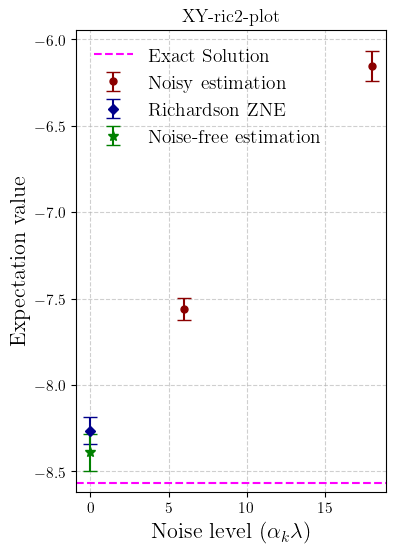

In [9]:
xy_ric2_plt = plot_zne_result(
    data=ALL_PROCESSED_DATA["xy-ric2"],
    extrapol_target=EXTRAPOL_TARGET,
    exact_solution=EXACT_SOL,
    plot_colors=plot_colors,
    plot_title="XY-ric2-plot",
    output_dir=f"reports/{timestamp}/plots",
    plot_file_name="xy_ric2.eps",
)

### #2 ising-ric2-plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports/20251112-121108/plots' folder): isng_ric2.eps
{'vqe': {'mean': -6.515074048169126, 'std': 0.4689932283581614},
 'redundant': {'sorted_noise_levels': [6, 18],
               'mean': [-6.515074048169157, -5.449144285565891],
               'std': [0.46899322835817936, 0.38249926927014455]},
 'zne': {'mean': -7.04803892947079, 'std': 0.5144850732068441},
 'noiseoff': {'mean': -7.164653802388168, 'std': 0.25530353672165906}}


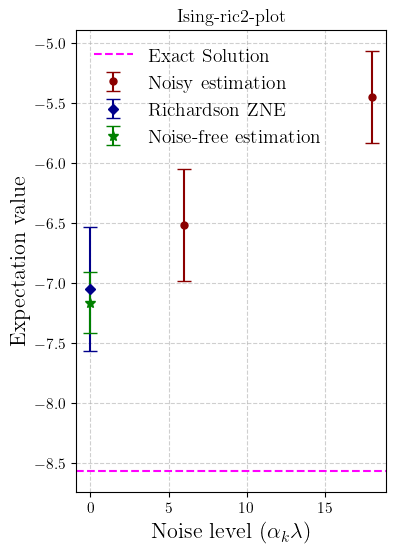

In [10]:
ising_ric2_plt = plot_zne_result(
    data=ALL_PROCESSED_DATA["ising-ric2"],
    extrapol_target=EXTRAPOL_TARGET,
    exact_solution=EXACT_SOL,
    plot_colors=plot_colors,
    plot_title="Ising-ric2-plot",
    output_dir=f"reports/{timestamp}/plots",
    plot_file_name="isng_ric2.eps",
)

### #3 heisenberg-ric2 plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports/20251112-121108/plots' folder): heisenberg_ric2.eps
{'vqe': {'mean': -6.262186941313465, 'std': 0.1777658759700855},
 'redundant': {'sorted_noise_levels': [6, 18],
               'mean': [-6.2621869413134075, -4.924188509397443],
               'std': [0.17776587597006646, 0.22076353943512317]},
 'zne': {'mean': -6.931186157271389, 'std': 0.16633300495826034},
 'noiseoff': {'mean': -6.726340893325717, 'std': 0.32239340076018347}}


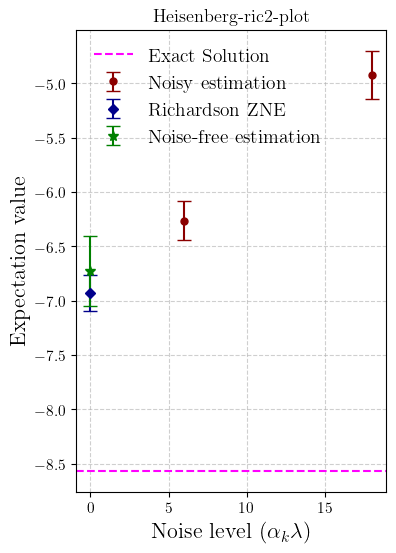

In [11]:
heisenberg_ric2_plt = plot_zne_result(
    data=ALL_PROCESSED_DATA["heisenberg-ric2"],
    extrapol_target=EXTRAPOL_TARGET,
    exact_solution=EXACT_SOL,
    plot_colors=plot_colors,
    plot_title="Heisenberg-ric2-plot",
    output_dir=f"reports/{timestamp}/plots",
    plot_file_name="heisenberg_ric2.eps",
)

### #4 Compiled ric-2 plots

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Compiled figure saved: reports/20251112-121108/plots/compiled_ric2.eps


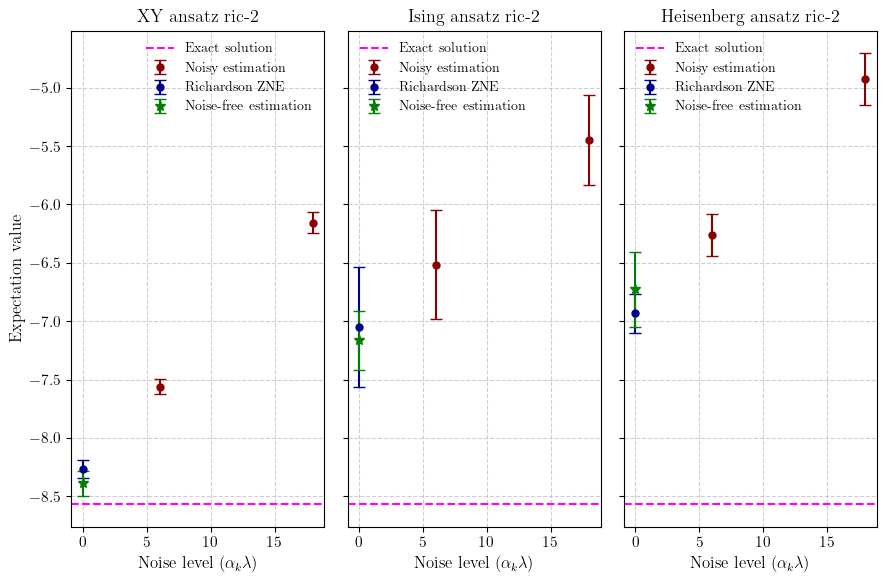

In [12]:
plot_titles = {
    "xy": "XY ansatz ric-2",
    "ising": "Ising ansatz ric-2",
    "heisenberg": "Heisenberg ansatz ric-2"
}

models_to_plot = ["xy-ric2", "ising-ric2", "heisenberg-ric2"]

ric2_compiled_plt = compile_zne_subplots(
    data=ALL_PROCESSED_DATA,
    models=models_to_plot,
    plot_titles=plot_titles,
    plot_colors=plot_colors,
    exact_solution=EXACT_SOL,
    extrapol_target=EXTRAPOL_TARGET,
    ncols=3,
    figsize=(9, 6),
    output_dir=f"reports/{timestamp}/plots",
    filename_prefix="compiled_ric2"
)

### #5 xy-ric3 plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports/20251112-121108/plots' folder): xy_ric3_uniform-scaling.eps
{'vqe': {'mean': -7.561074977738365, 'std': 0.06520153937684584},
 'redundant': {'sorted_noise_levels': [6, 18, 30],
               'mean': [-7.561074977738326,
                        -6.1551797250619025,
                        -5.04734629004842],
               'std': [0.06520153937683842,
                       0.08758142716528244,
                       0.12294947332707173]},
 'zne': {'mean': -8.375795785700143, 'std': 0.08181630381047383},
 'noiseoff': {'mean': -8.389289615512132, 'std': 0.10862246962636332}}


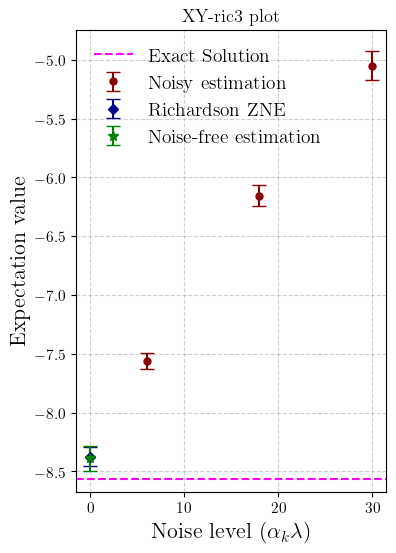

In [13]:
xy_ric3_plt = plot_zne_result(
    data=ALL_PROCESSED_DATA["xy-ric3-uniform-scaling"],
    extrapol_target=EXTRAPOL_TARGET,
    exact_solution=EXACT_SOL,
    plot_colors=plot_colors,
    plot_title="XY-ric3 plot",
    output_dir=f"reports/{timestamp}/plots",
    plot_file_name="xy_ric3_uniform-scaling.eps",
)

### #6 ising-ric3 plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports/20251112-121108/plots' folder): ising_ric3_uniform-scaling.eps
{'vqe': {'mean': -6.515074048169126, 'std': 0.4689932283581614},
 'redundant': {'sorted_noise_levels': [6, 18, 30],
               'mean': [-6.515074048169157,
                        -5.449144285565891,
                        -4.563699593649003],
               'std': [0.4689932283581794,
                       0.38249926927014455,
                       0.3242492229972746]},
 'zne': {'mean': -7.115720830978182, 'std': 0.5237328869728071},
 'noiseoff': {'mean': -7.164653802388168, 'std': 0.25530353672165906}}


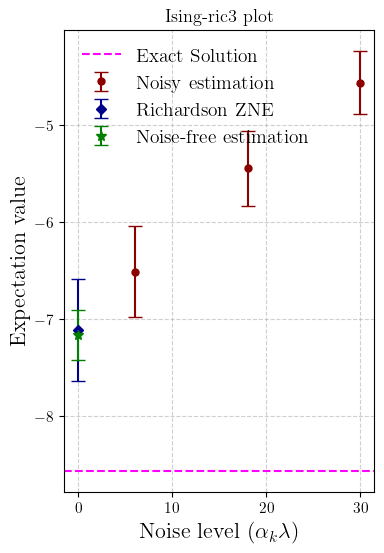

In [14]:
ising_ric3_plt = plot_zne_result(
    data=ALL_PROCESSED_DATA["ising-ric3-uniform-scaling"],
    extrapol_target=EXTRAPOL_TARGET,
    exact_solution=EXACT_SOL,
    plot_colors=plot_colors,
    plot_title="Ising-ric3 plot",
    output_dir=f"reports/{timestamp}/plots",
    plot_file_name="ising_ric3_uniform-scaling.eps",
)

### #7 heisenberg-ric3 plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports/20251112-121108/plots' folder): heisenberg_ric3_uniform-scaling.eps
{'vqe': {'mean': -6.262186941313465, 'std': 0.1777658759700855},
 'redundant': {'sorted_noise_levels': [6, 18, 30],
               'mean': [-6.2621869413134075,
                        -4.924188509397443,
                        -3.8662749695160628],
               'std': [0.1777658759700666,
                       0.22076353943512309,
                       0.2520449862906288]},
 'zne': {'mean': -7.0362179917843575, 'std': 0.16244327091903585},
 'noiseoff': {'mean': -6.726340893325717, 'std': 0.32239340076018347}}


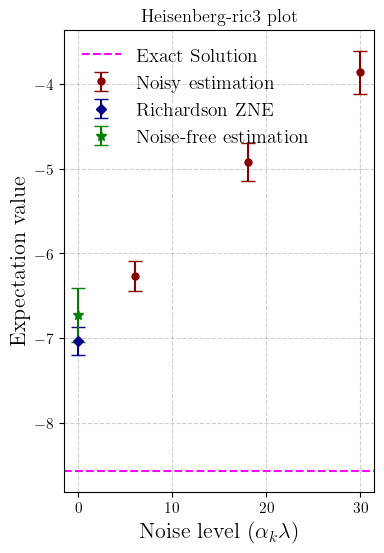

In [15]:
heisenberg_ric3_plt = plot_zne_result(
    data=ALL_PROCESSED_DATA["heisenberg-ric3-uniform-scaling"],
    extrapol_target=EXTRAPOL_TARGET,
    exact_solution=EXACT_SOL,
    plot_colors=plot_colors,
    plot_title="Heisenberg-ric3 plot",
    output_dir=f"reports/{timestamp}/plots",
    plot_file_name="heisenberg_ric3_uniform-scaling.eps",
)

### #8 Compiled ric-3 plots

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Compiled figure saved: reports/20251112-121108/plots/compiled_ric3.eps


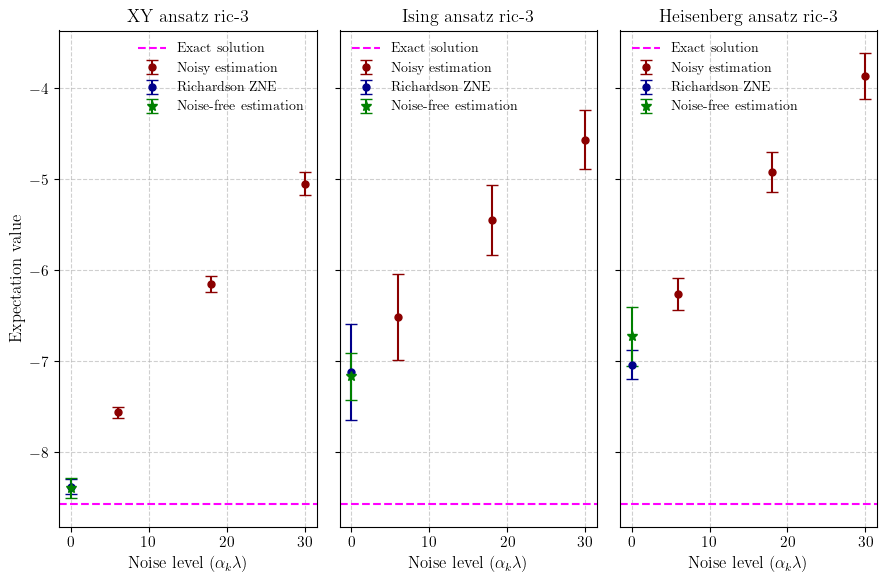

In [16]:
plot_titles = {
    "xy": "XY ansatz ric-3",
    "ising": "Ising ansatz ric-3",
    "heisenberg": "Heisenberg ansatz ric-3"
}

models_to_plot = ["xy-ric3-uniform-scaling", "ising-ric3-uniform-scaling", "heisenberg-ric3-uniform-scaling"]

ric3_compiled_plt = compile_zne_subplots(
    data=ALL_PROCESSED_DATA,
    models=models_to_plot,
    plot_titles=plot_titles,
    plot_colors=plot_colors,
    exact_solution=EXACT_SOL,
    extrapol_target=EXTRAPOL_TARGET,
    ncols=3,
    figsize=(9, 6),
    output_dir=f"reports/{timestamp}/plots",
    filename_prefix="compiled_ric3"
)

### #9 Compiled ric-4 plots

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Compiled figure saved: reports/20251112-121108/plots/compiled_ric4.eps


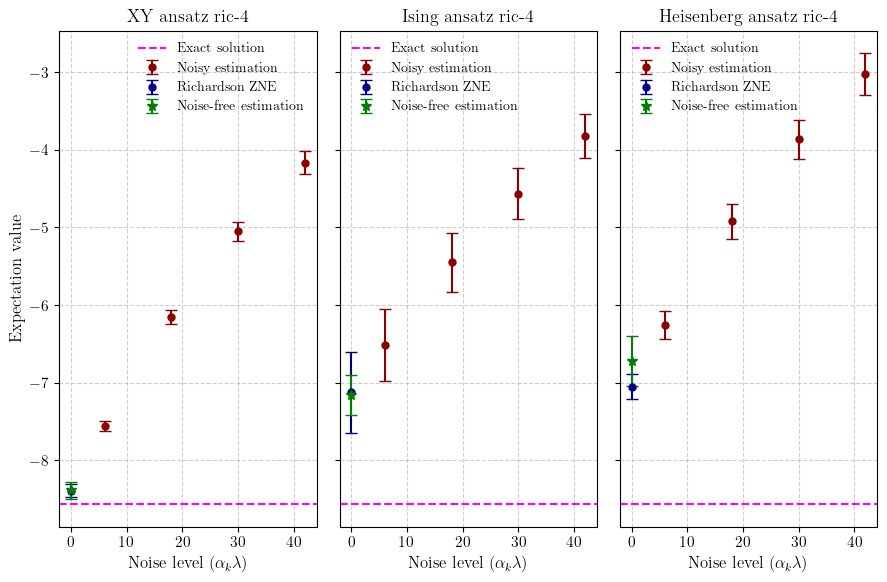

In [17]:
plot_titles = {
    "xy": "XY ansatz ric-4",
    "ising": "Ising ansatz ric-4",
    "heisenberg": "Heisenberg ansatz ric-4"
}

models_to_plot = ["xy-ric4-uniform-scaling", "ising-ric4-uniform-scaling", "heisenberg-ric4-uniform-scaling"]

ric4_compiled_plt = compile_zne_subplots(
    data=ALL_PROCESSED_DATA,
    models=models_to_plot,
    plot_titles=plot_titles,
    plot_colors=plot_colors,
    exact_solution=EXACT_SOL,
    extrapol_target=EXTRAPOL_TARGET,
    ncols=3,
    figsize=(9, 6),
    output_dir=f"reports/{timestamp}/plots",
    filename_prefix="compiled_ric4"
)

## (7) Summary

=== Summary Table ===
                        Description            Simulation          Mean ± Std
0                           xy-ric2                   vqe  -7.56107 ± 0.06520
1                           xy-ric2   redundant (noise=6)  -7.56107 ± 0.06520
2                           xy-ric2  redundant (noise=18)  -6.15518 ± 0.08758
3                           xy-ric2                   zne  -8.26402 ± 0.07690
4                           xy-ric2              noiseoff  -8.38929 ± 0.10862
..                              ...                   ...                 ...
58  heisenberg-ric4-uniform-scaling  redundant (noise=30)  -3.86627 ± 0.25204
59  heisenberg-ric4-uniform-scaling  redundant (noise=42)  -3.02209 ± 0.26938
60  heisenberg-ric4-uniform-scaling                   zne  -7.05696 ± 0.16129
61  heisenberg-ric4-uniform-scaling              noiseoff  -6.72634 ± 0.32239
62                                                                           

[63 rows x 3 columns]


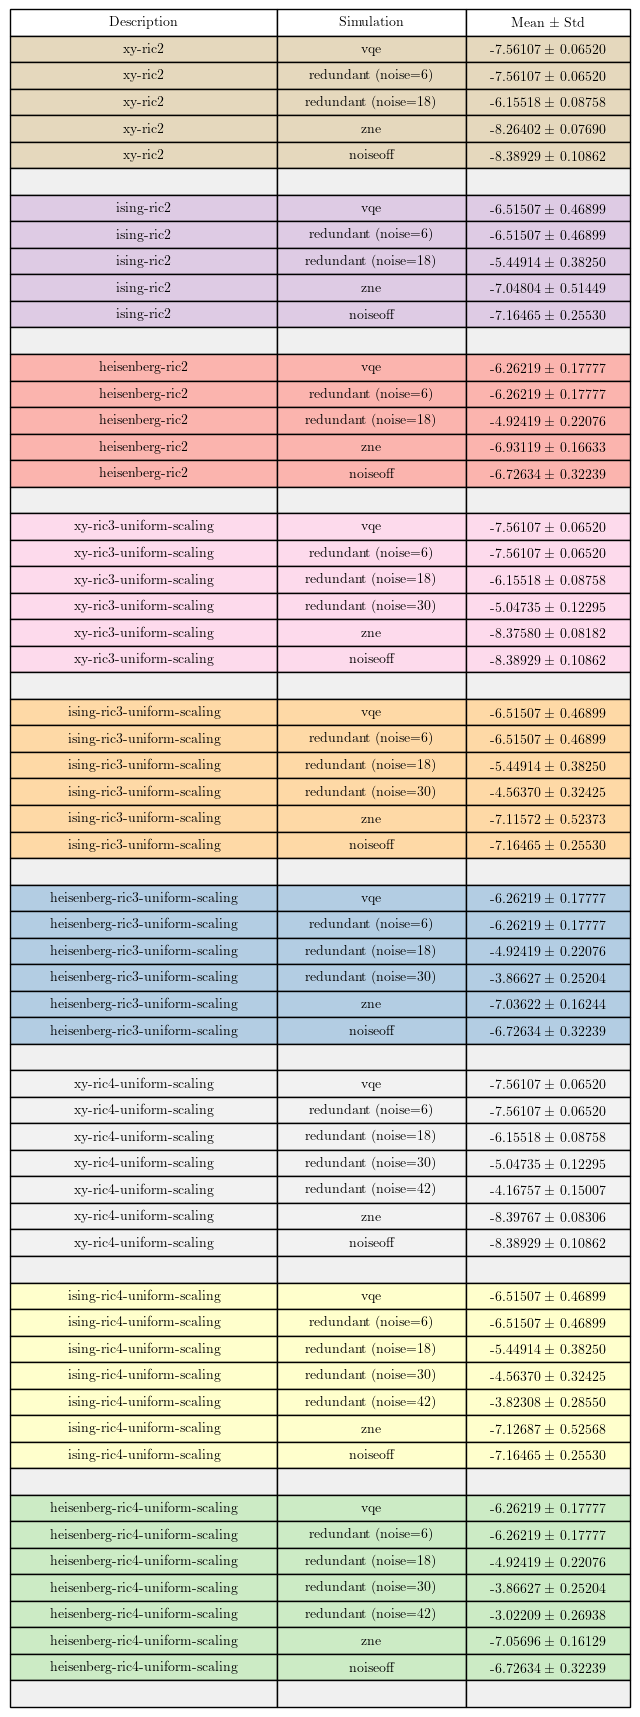

In [18]:
df_summary, fig = summarize_zne_results(
    ALL_PROCESSED_DATA=ALL_PROCESSED_DATA,
    selected_models=ZNE_MODELS,
    output_dir=f"reports/{timestamp}/artifacts",
    decimals=5,
    font_size=10,
    row_scale=1.3,
    save_name=f"zne_summary",
    save_formats=["eps","csv","latex"]
)

# Appendix
---

### PDF reports

In [19]:
CONFIG_SUMMARY: dict = {
    "xy": ALL_RAW_DATA["xy-ric2"]["vqe"][0]["config"],
    "ising": ALL_RAW_DATA["ising-ric2"]["vqe"][0]["config"],
    "heisenberg": ALL_RAW_DATA["heisenberg-ric2"]["vqe"][0]["config"],
}
ALL_PLOTS = [
    ric2_compiled_plt,
    ric3_compiled_plt, 
    ric4_compiled_plt
]

In [20]:
HEIGHT = 0.2
WIDTH = 5
FILE_NAME = f"reports/{timestamp}/artifacts/zne_summary.pdf"

# Flatten deeply nested dicts
def flatten_config(config, prefix=""):
    flat = {}
    for k, v in config.items():
        full_key = f"{prefix}{k}"
        if isinstance(v, dict):
            flat.update(flatten_config(v, prefix=full_key + "."))
        else:
            flat[full_key] = v
    return flat

def render_model_config_page(model_name, config_dict):
    flat_config = flatten_config(config_dict)
    df = pd.DataFrame(list(flat_config.items()), columns=["Parameter", "Value"])

    # Estimate height dynamically
    row_height = HEIGHT  # inches per row
    max_width = WIDTH  # keep A4 landscape width if needed
    fig_height = max(2, min(len(df) * row_height + 1.5, 11))

    fig = plt.figure(figsize=(max_width, fig_height))
    ax = fig.add_axes([0, 0, 1, 1])  # Full area, no margin
    ax.axis('off')

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='left',
        loc='center',
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.3)  # Adjust row height for readability

    # Color header row
    for j in range(len(df.columns)):
        table[(0, j)].set_fontsize(9)
        table[(0, j)].set_facecolor("#dddddd")
        table[(0, j)].set_text_props(weight='bold')

    # Add title manually
    fig.text(0.5, 0.98, f"{model_name.upper()} VQE CONFIGURATION", ha='center', fontsize=12, weight='bold')

    return fig

if pdf_reports:
    with PdfPages(FILE_NAME) as pdf:
        # Save a main figure (if any)
        pdf.savefig(fig, bbox_inches='tight', pad_inches=0.05)
        plt.close(fig)
        
        # Save multiple stored figures
        for stored_fig in ALL_PLOTS:
            pdf.savefig(stored_fig, bbox_inches='tight', pad_inches=0.05)
            plt.close(stored_fig)
        
        # Save config summary pages
        for model, config in CONFIG_SUMMARY.items():
            config_fig = render_model_config_page(model, config)
            pdf.savefig(config_fig, bbox_inches='tight', pad_inches=0.1)
            plt.close(config_fig)
        
        print("Result summary saved as PDF:", FILE_NAME)
else:
    print("PDF report generation skipped.")

Result summary saved as PDF: reports/20251112-121108/artifacts/zne_summary.pdf


PDF report with detailed setup exporting

In [21]:
if detailed_reports:
    export_raw_data_wrapped(ALL_RAW_DATA, pdf_filename=f"reports/{timestamp}/artifacts/big_json.pdf")
else:
    print("Detailed raw data PDF export skipped.")

✅ PDF saved as 'reports/20251112-121108/artifacts/big_json.pdf'


### Latex table

In [22]:
def generate_latex_table_ric4(all_data):
    """
    Generate a ready-to-copy LaTeX table for ric4 results only.
    Uses inline math $...$ with \pm.
    """
    def fmt(m, s):
        return f"${m:.3f} \\pm {s:.3f}$"
    
    # Pick ric4 keys
    xy_key = [k for k in all_data if k.startswith("xy") and "ric4" in k][0]
    ising_key = [k for k in all_data if k.startswith("ising") and "ric4" in k][0]
    heis_key = [k for k in all_data if k.startswith("heisenberg") and "ric4" in k][0]
    
    table = r"""\begin{table}[h]
\caption{Result summary for Richardson ZNE where the ansatz has noise-free time evolution. The corresponding graphs are plotted in Figure \ref{graph-noisefree-timevo}.}
\begin{tabular}{@{}llll@{}}
\toprule
  & XY-ansatz  & Ising-ansatz  & Heisenberg-ansatz\\
\midrule
"""
    # Noise-free estimation
    table += f"Noise-free estimation & {fmt(all_data[xy_key]['noiseoff']['mean'], all_data[xy_key]['noiseoff']['std'])} & "
    table += f"{fmt(all_data[ising_key]['noiseoff']['mean'], all_data[ising_key]['noiseoff']['std'])} & "
    table += f"{fmt(all_data[heis_key]['noiseoff']['mean'], all_data[heis_key]['noiseoff']['std'])} \\\\\n"
    table += r"\midrule" + "\n"
    
    # Boosted noise
    max_levels = max(len(all_data[xy_key]['redundant']['sorted_noise_levels']),
                     len(all_data[ising_key]['redundant']['sorted_noise_levels']),
                     len(all_data[heis_key]['redundant']['sorted_noise_levels']))
    
    for i in range(max_levels):
        row = ""
        # XY
        if i < len(all_data[xy_key]['redundant']['sorted_noise_levels']):
            nl = all_data[xy_key]['redundant']['sorted_noise_levels'][i]
            row += f"Boosted noise={nl} & "
            row += fmt(all_data[xy_key]['redundant']['mean'][i], all_data[xy_key]['redundant']['std'][i]) + " & "
        else:
            row += " & & "
        # Ising
        if i < len(all_data[ising_key]['redundant']['sorted_noise_levels']):
            row += fmt(all_data[ising_key]['redundant']['mean'][i], all_data[ising_key]['redundant']['std'][i]) + " & "
        else:
            row += " & "
        # Heisenberg
        if i < len(all_data[heis_key]['redundant']['sorted_noise_levels']):
            row += fmt(all_data[heis_key]['redundant']['mean'][i], all_data[heis_key]['redundant']['std'][i])
        row += r" \\"
        table += row + "\n"
    
    table += r"\midrule" + "\n"
    
    # Richardson ZNE
    table += "Richardson ZNE value & "
    table += fmt(all_data[xy_key]['zne']['mean'], all_data[xy_key]['zne']['std']) + " & "
    table += fmt(all_data[ising_key]['zne']['mean'], all_data[ising_key]['zne']['std']) + " & "
    table += fmt(all_data[heis_key]['zne']['mean'], all_data[heis_key]['zne']['std']) + r" \\" + "\n"
    
    table += r"""\bottomrule
\end{tabular}
\label{table-noisefree-timeevo-richardson}
\end{table}"""
    
    return table

# Usage:
latex_table_ric4 = generate_latex_table_ric4(ALL_PROCESSED_DATA)
print(latex_table_ric4)


\begin{table}[h]
\caption{Result summary for Richardson ZNE where the ansatz has noise-free time evolution. The corresponding graphs are plotted in Figure \ref{graph-noisefree-timevo}.}
\begin{tabular}{@{}llll@{}}
\toprule
  & XY-ansatz  & Ising-ansatz  & Heisenberg-ansatz\\
\midrule
Noise-free estimation & $-8.389 \pm 0.109$ & $-7.165 \pm 0.255$ & $-6.726 \pm 0.322$ \\
\midrule
Boosted noise=6 & $-7.561 \pm 0.065$ & $-6.515 \pm 0.469$ & $-6.262 \pm 0.178$ \\
Boosted noise=18 & $-6.155 \pm 0.088$ & $-5.449 \pm 0.382$ & $-4.924 \pm 0.221$ \\
Boosted noise=30 & $-5.047 \pm 0.123$ & $-4.564 \pm 0.324$ & $-3.866 \pm 0.252$ \\
Boosted noise=42 & $-4.168 \pm 0.150$ & $-3.823 \pm 0.285$ & $-3.022 \pm 0.269$ \\
\midrule
Richardson ZNE value & $-8.398 \pm 0.083$ & $-7.127 \pm 0.526$ & $-7.057 \pm 0.161$ \\
\bottomrule
\end{tabular}
\label{table-noisefree-timeevo-richardson}
\end{table}


### Grid plotting

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ ZNE grid saved to: reports/20251112-121108/plots/grid_plot_ric2_ric3.eps


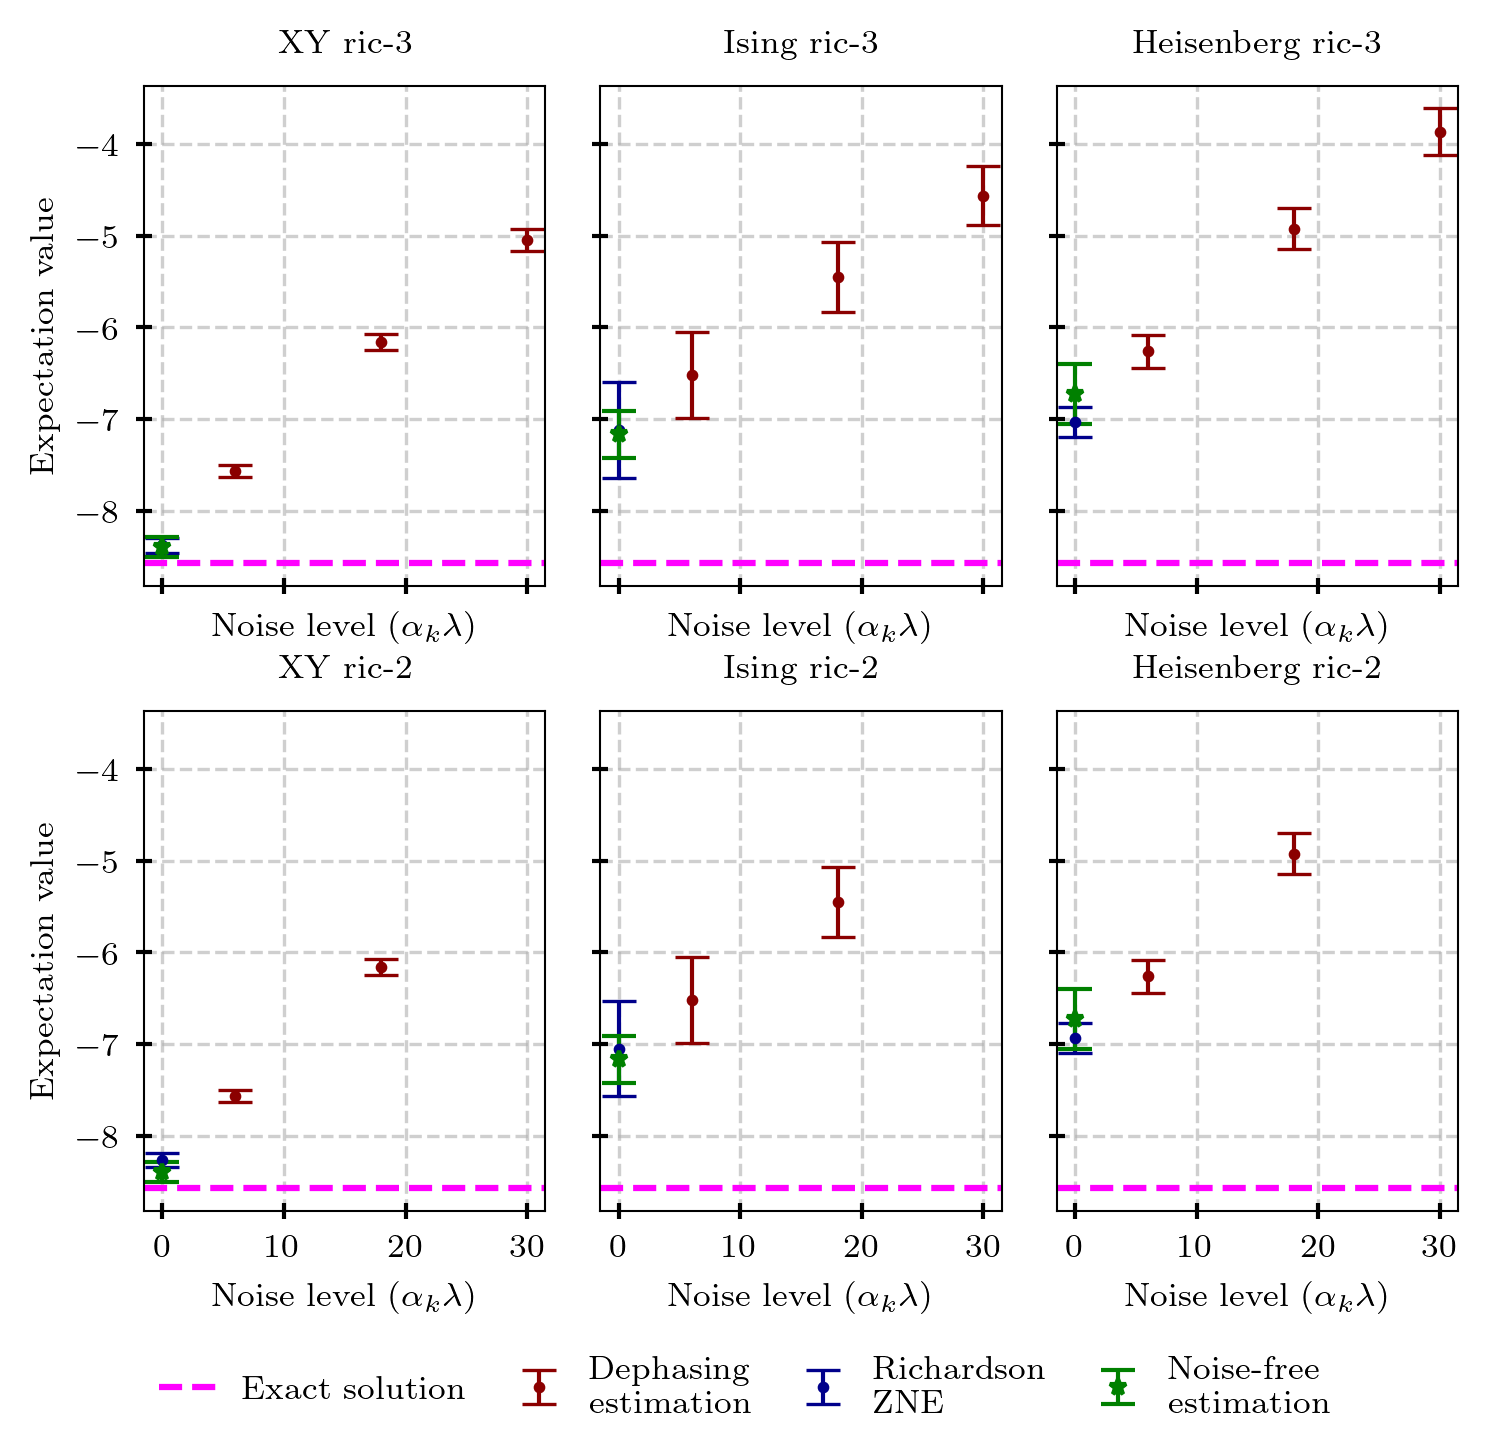

In [23]:
from nbutils.zne_grid_plot import zne_grid

font_size = 8
models_to_plot = [
    "xy-ric3-uniform-scaling",
    "ising-ric3-uniform-scaling",
    "heisenberg-ric3-uniform-scaling",
    "xy-ric2",
    "ising-ric2",
    "heisenberg-ric2"
]

plot_titles = [
    "XY ric-3",
    "Ising ric-3",
    "Heisenberg ric-3",
    "XY ric-2",
    "Ising ric-2",
    "Heisenberg ric-2"
]

zne_grid(
    data=ALL_PROCESSED_DATA,
    models=models_to_plot,
    plot_titles=plot_titles,
    plot_colors=plot_colors,
    exact_solution=EXACT_SOL,
    extrapol_target=EXTRAPOL_TARGET,
    ncols=3,
    figsize=(5, 5),
    sharex=True,
    sharey=True,
    global_legend=True,
    title_fontsize=font_size,
    label_fontsize=font_size,
    tick_fontsize=font_size,
    legend_fontsize=font_size,
    border_width=0.5,
    marker_size=2,
    output_dir=f"reports/{timestamp}/plots",
    filename_prefix="grid_plot_ric2_ric3",
    leg_noise_type="Dephasing \n"
)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ ZNE grid saved to: reports/20251112-121108/plots/grid_plot_ric4.eps


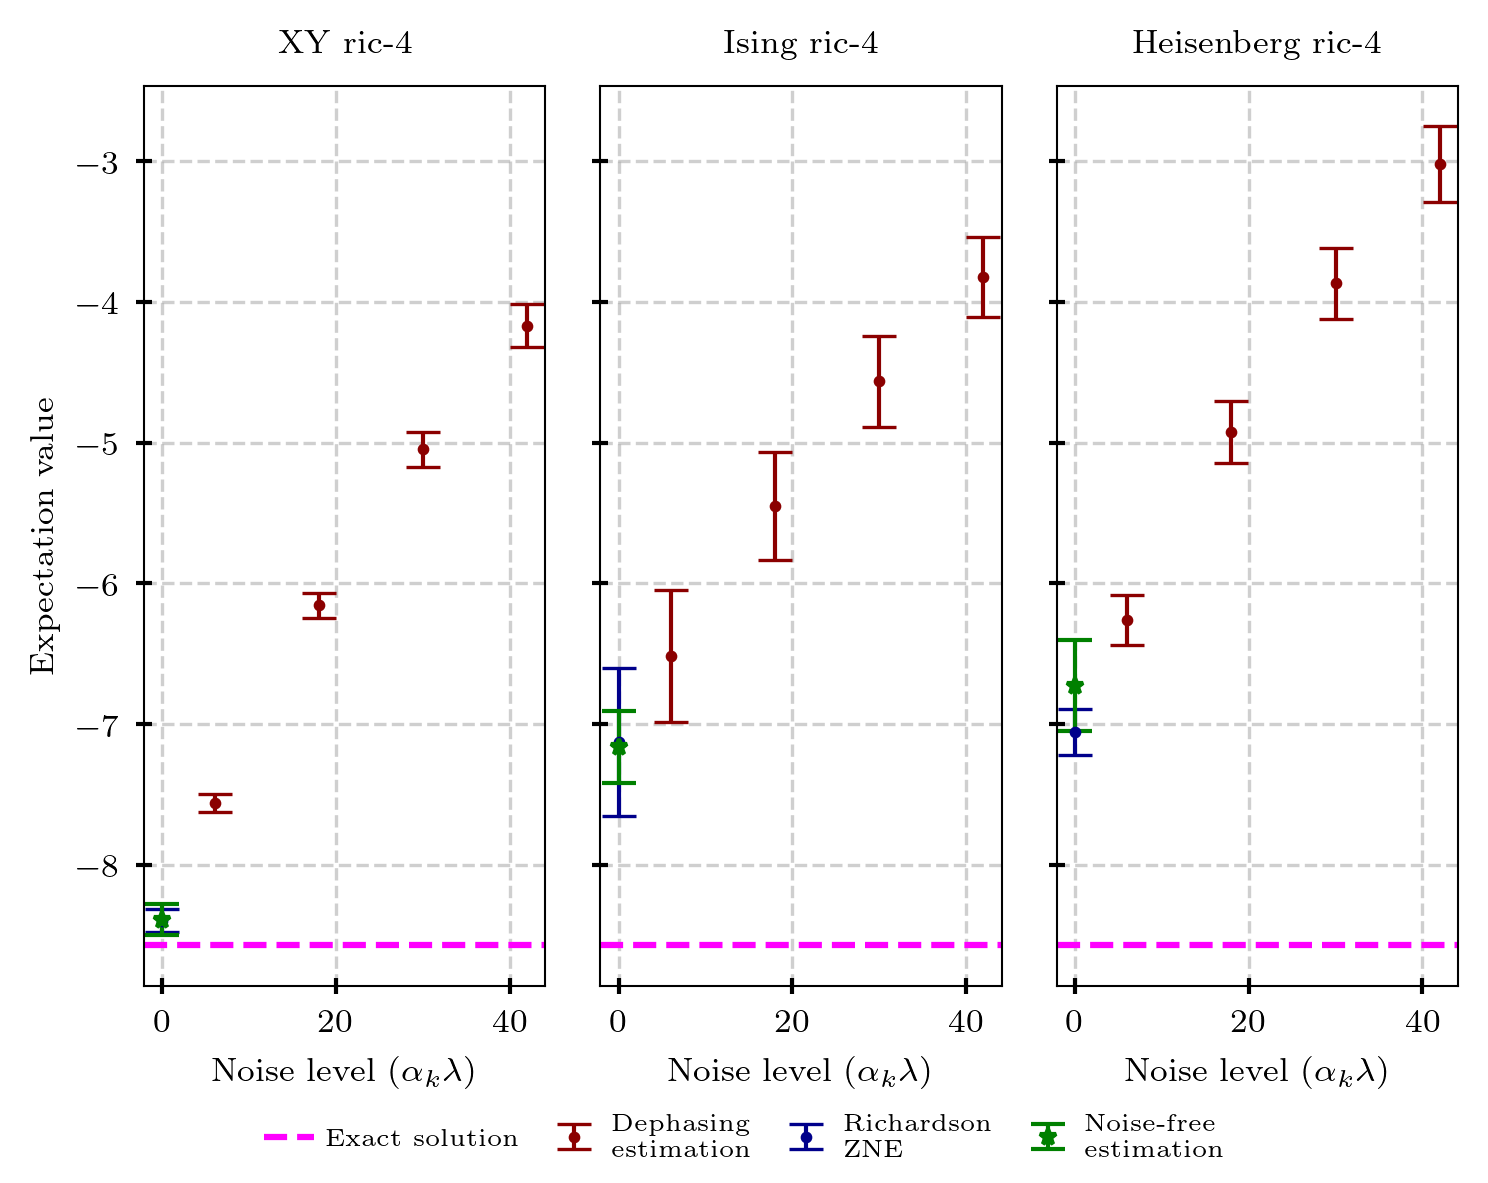

In [24]:
models_to_plot = [
    "xy-ric4-uniform-scaling",
    "ising-ric4-uniform-scaling",
    "heisenberg-ric4-uniform-scaling"
]

plot_titles = [
    "XY ric-4",
    "Ising ric-4",
    "Heisenberg ric-4"
]

zne_grid(
    data=ALL_PROCESSED_DATA,
    models=models_to_plot,
    plot_titles=plot_titles,
    plot_colors=plot_colors,
    exact_solution=EXACT_SOL,
    extrapol_target=EXTRAPOL_TARGET,
    ncols=3,
    figsize=(5, 4),
    sharex=True,
    sharey=True,
    global_legend=True,
    title_fontsize=font_size,
    label_fontsize=font_size,
    tick_fontsize=font_size,
    legend_fontsize=6,
    border_width=0.5,
    marker_size=2,
    output_dir=f"reports/{timestamp}/plots",
    filename_prefix="grid_plot_ric4",
    leg_noise_type="Dephasing \n"
)

### ric-2 and ric-3 latex table

In [25]:
template_table_ric2_ric3 = Template(r"""
\begin{table}[h]
\caption{$caption}
\begin{tabular}{@{}llll@{}}
\toprule
  & XY-ansatz  & Ising-ansatz  & Heisenberg-ansatz\\
\midrule
ric-2 ZNE & $$${xy_ric_2_mean} \pm ${xy_ric_2_std}$$ & $$${ising_ric_2_mean} \pm ${ising_ric_2_std}$$ & $$${heis_ric_2_mean} \pm ${heis_ric_2_std}$$ \\
ric-3 ZNE & $$${xy_ric_3_mean} \pm ${xy_ric_3_std}$$ & $$${ising_ric_3_mean} \pm ${ising_ric_3_std}$$ & $$${heis_ric_3_mean} \pm ${heis_ric_3_std}$$ \\
\bottomrule
\end{tabular}
\label{$label}
\end{table}
""")

In [26]:
table_ric2_ric3_latex = template_table_ric2_ric3.substitute(
    caption="Result summary for 2-point (ric-2) and 3-point (ric-3) Richardson ZNEs in Figure \\ref{---------------------}.",
    label="table-dephasing-noise-free-time-evo",

    xy_ric_2_mean=f"{ALL_PROCESSED_DATA['xy-ric2']['zne']['mean']:.3f}",
    xy_ric_2_std=f"{ALL_PROCESSED_DATA['xy-ric2']['zne']['std']:.3f}",

    ising_ric_2_mean=f"{ALL_PROCESSED_DATA['ising-ric2']['zne']['mean']:.3f}",
    ising_ric_2_std=f"{ALL_PROCESSED_DATA['ising-ric2']['zne']['std']:.3f}",

    heis_ric_2_mean=f"{ALL_PROCESSED_DATA['heisenberg-ric2']['zne']['mean']:.3f}",
    heis_ric_2_std=f"{ALL_PROCESSED_DATA['heisenberg-ric2']['zne']['std']:.3f}",

    xy_ric_3_mean=f"{ALL_PROCESSED_DATA['xy-ric3-uniform-scaling']['zne']['mean']:.3f}",
    xy_ric_3_std=f"{ALL_PROCESSED_DATA['xy-ric3-uniform-scaling']['zne']['std']:.3f}",

    ising_ric_3_mean=f"{ALL_PROCESSED_DATA['ising-ric3-uniform-scaling']['zne']['mean']:.3f}",
    ising_ric_3_std=f"{ALL_PROCESSED_DATA['ising-ric3-uniform-scaling']['zne']['std']:.3f}",

    heis_ric_3_mean=f"{ALL_PROCESSED_DATA['heisenberg-ric3-uniform-scaling']['zne']['mean']:.3f}",
    heis_ric_3_std=f"{ALL_PROCESSED_DATA['heisenberg-ric3-uniform-scaling']['zne']['std']:.3f}",
)
print(table_ric2_ric3_latex)


\begin{table}[h]
\caption{Result summary for 2-point (ric-2) and 3-point (ric-3) Richardson ZNEs in Figure \ref{---------------------}.}
\begin{tabular}{@{}llll@{}}
\toprule
  & XY-ansatz  & Ising-ansatz  & Heisenberg-ansatz\\
\midrule
ric-2 ZNE & $-8.264 \pm 0.077$ & $-7.048 \pm 0.514$ & $-6.931 \pm 0.166$ \\
ric-3 ZNE & $-8.376 \pm 0.082$ & $-7.116 \pm 0.524$ & $-7.036 \pm 0.162$ \\
\bottomrule
\end{tabular}
\label{table-dephasing-noise-free-time-evo}
\end{table}



### ric-4 latex table

In [27]:
template_table_ric4 = Template(r"""
\begin{table}[h]
\caption{$caption}
\begin{tabular}{@{}llll@{}}
\toprule
  & XY-ansatz  & Ising-ansatz  & Heisenberg-ansatz\\
\midrule
Noise-free estimation & $$${xy_nf_mean} \pm ${xy_nf_std}$$ & $$${ising_nf_mean} \pm ${ising_nf_std}$$ & $$${heis_nf_mean} \pm ${heis_nf_std}$$ \\
\midrule
Base noise=$base_noise_label & $$${xy_base_mean} \pm ${xy_base_std}$$ & $$${ising_base_mean} \pm ${ising_base_std}$$ & $$${heis_base_mean} \pm ${heis_base_std}$$ \\
Boosted noise=$boost1_noise_label & $$${xy_boost1_mean} \pm ${xy_boost1_std}$$ & $$${ising_boost1_mean} \pm ${ising_boost1_std}$$ & $$${heis_boost1_mean} \pm ${heis_boost1_std}$$ \\
Boosted noise=$boost2_noise_label & $$${xy_boost2_mean} \pm ${xy_boost2_std}$$ & $$${ising_boost2_mean} \pm ${ising_boost2_std}$$ & $$${heis_boost2_mean} \pm ${heis_boost2_std}$$ \\
Boosted noise=$boost3_noise_label & $$${xy_boost3_mean} \pm ${xy_boost3_std}$$ & $$${ising_boost3_mean} \pm ${ising_boost3_std}$$ & $$${heis_boost3_mean} \pm ${heis_boost3_std}$$ \\
\midrule
Richardson ZNE value & $$${xy_zne_mean} \pm ${xy_zne_std}$$ & $$${ising_zne_mean} \pm ${ising_zne_std}$$ & $$${heis_zne_mean} \pm ${heis_zne_std}$$ \\
\bottomrule
\end{tabular}
\label{$label}
\end{table}
""")


In [28]:
table_ric4_latex = template_table_ric4.substitute(
    caption="Result summary for graphs in Figure\\ref{graph-depol-time-evo-noise-free}.",
    label="table-depol-noise-free-time-evo",

    # noise free
    xy_nf_mean=f"{ALL_PROCESSED_DATA['xy-ric4-uniform-scaling']['noiseoff']['mean']:.3f}",
    xy_nf_std=f"{ALL_PROCESSED_DATA['xy-ric4-uniform-scaling']['noiseoff']['std']:.3f}",
    ising_nf_mean=f"{ALL_PROCESSED_DATA['ising-ric4-uniform-scaling']['noiseoff']['mean']:.3f}",
    ising_nf_std=f"{ALL_PROCESSED_DATA['ising-ric4-uniform-scaling']['noiseoff']['std']:.3f}",
    heis_nf_mean=f"{ALL_PROCESSED_DATA['heisenberg-ric4-uniform-scaling']['noiseoff']['mean']:.3f}",
    heis_nf_std=f"{ALL_PROCESSED_DATA['heisenberg-ric4-uniform-scaling']['noiseoff']['std']:.3f}",

    # noise labels
    base_noise_label="6",
    boost1_noise_label="18",
    boost2_noise_label="30",
    boost3_noise_label="42",

    # base
    xy_base_mean=f"{ALL_PROCESSED_DATA['xy-ric4-uniform-scaling']['redundant']['mean'][0]:.3f}",
    xy_base_std=f"{ALL_PROCESSED_DATA['xy-ric4-uniform-scaling']['redundant']['std'][0]:.3f}",
    ising_base_mean=f"{ALL_PROCESSED_DATA['ising-ric4-uniform-scaling']['redundant']['mean'][0]:.3f}",
    ising_base_std=f"{ALL_PROCESSED_DATA['ising-ric4-uniform-scaling']['redundant']['std'][0]:.3f}",
    heis_base_mean=f"{ALL_PROCESSED_DATA['heisenberg-ric4-uniform-scaling']['redundant']['mean'][0]:.3f}",
    heis_base_std=f"{ALL_PROCESSED_DATA['heisenberg-ric4-uniform-scaling']['redundant']['std'][0]:.3f}",

    # boosted 1 (index 1)
    xy_boost1_mean=f"{ALL_PROCESSED_DATA['xy-ric4-uniform-scaling']['redundant']['mean'][1]:.3f}",
    xy_boost1_std=f"{ALL_PROCESSED_DATA['xy-ric4-uniform-scaling']['redundant']['std'][1]:.3f}",
    ising_boost1_mean=f"{ALL_PROCESSED_DATA['ising-ric4-uniform-scaling']['redundant']['mean'][1]:.3f}",
    ising_boost1_std=f"{ALL_PROCESSED_DATA['ising-ric4-uniform-scaling']['redundant']['std'][1]:.3f}",
    heis_boost1_mean=f"{ALL_PROCESSED_DATA['heisenberg-ric4-uniform-scaling']['redundant']['mean'][1]:.3f}",
    heis_boost1_std=f"{ALL_PROCESSED_DATA['heisenberg-ric4-uniform-scaling']['redundant']['std'][1]:.3f}",

    # boosted 2 (index 2)
    xy_boost2_mean=f"{ALL_PROCESSED_DATA['xy-ric4-uniform-scaling']['redundant']['mean'][2]:.3f}",
    xy_boost2_std=f"{ALL_PROCESSED_DATA['xy-ric4-uniform-scaling']['redundant']['std'][2]:.3f}",
    ising_boost2_mean=f"{ALL_PROCESSED_DATA['ising-ric4-uniform-scaling']['redundant']['mean'][2]:.3f}",
    ising_boost2_std=f"{ALL_PROCESSED_DATA['ising-ric4-uniform-scaling']['redundant']['std'][2]:.3f}",
    heis_boost2_mean=f"{ALL_PROCESSED_DATA['heisenberg-ric4-uniform-scaling']['redundant']['mean'][2]:.3f}",
    heis_boost2_std=f"{ALL_PROCESSED_DATA['heisenberg-ric4-uniform-scaling']['redundant']['std'][2]:.3f}",

    # boosted 3 (index 3)
    xy_boost3_mean=f"{ALL_PROCESSED_DATA['xy-ric4-uniform-scaling']['redundant']['mean'][3]:.3f}",
    xy_boost3_std=f"{ALL_PROCESSED_DATA['xy-ric4-uniform-scaling']['redundant']['std'][3]:.3f}",
    ising_boost3_mean=f"{ALL_PROCESSED_DATA['ising-ric4-uniform-scaling']['redundant']['mean'][3]:.3f}",
    ising_boost3_std=f"{ALL_PROCESSED_DATA['ising-ric4-uniform-scaling']['redundant']['std'][3]:.3f}",
    heis_boost3_mean=f"{ALL_PROCESSED_DATA['heisenberg-ric4-uniform-scaling']['redundant']['mean'][3]:.3f}",
    heis_boost3_std=f"{ALL_PROCESSED_DATA['heisenberg-ric4-uniform-scaling']['redundant']['std'][3]:.3f}",

    # zne (fixed navigation)
    xy_zne_mean=f"{ALL_PROCESSED_DATA['xy-ric4-uniform-scaling']['zne']['mean']:.3f}",
    xy_zne_std=f"{ALL_PROCESSED_DATA['xy-ric4-uniform-scaling']['zne']['std']:.3f}",
    ising_zne_mean=f"{ALL_PROCESSED_DATA['ising-ric4-uniform-scaling']['zne']['mean']:.3f}",
    ising_zne_std=f"{ALL_PROCESSED_DATA['ising-ric4-uniform-scaling']['zne']['std']:.3f}",
    heis_zne_mean=f"{ALL_PROCESSED_DATA['heisenberg-ric4-uniform-scaling']['zne']['mean']:.3f}",
    heis_zne_std=f"{ALL_PROCESSED_DATA['heisenberg-ric4-uniform-scaling']['zne']['std']:.3f}",
)
print(table_ric4_latex)


\begin{table}[h]
\caption{Result summary for graphs in Figure\ref{graph-depol-time-evo-noise-free}.}
\begin{tabular}{@{}llll@{}}
\toprule
  & XY-ansatz  & Ising-ansatz  & Heisenberg-ansatz\\
\midrule
Noise-free estimation & $-8.389 \pm 0.109$ & $-7.165 \pm 0.255$ & $-6.726 \pm 0.322$ \\
\midrule
Base noise=6 & $-7.561 \pm 0.065$ & $-6.515 \pm 0.469$ & $-6.262 \pm 0.178$ \\
Boosted noise=18 & $-6.155 \pm 0.088$ & $-5.449 \pm 0.382$ & $-4.924 \pm 0.221$ \\
Boosted noise=30 & $-5.047 \pm 0.123$ & $-4.564 \pm 0.324$ & $-3.866 \pm 0.252$ \\
Boosted noise=42 & $-4.168 \pm 0.150$ & $-3.823 \pm 0.285$ & $-3.022 \pm 0.269$ \\
\midrule
Richardson ZNE value & $-8.398 \pm 0.083$ & $-7.127 \pm 0.526$ & $-7.057 \pm 0.161$ \\
\bottomrule
\end{tabular}
\label{table-depol-noise-free-time-evo}
\end{table}



### File writing for latex tables

In [29]:
# Ensure artifact dir exists
os.makedirs(artifact_dir, exist_ok=True)

to_write = {}

if "table_ric4_latex" in globals():
    to_write[os.path.join(artifact_dir, "table_ric4.tex")] = table_ric4_latex

if "table_ric2_ric3_latex" in globals():
    to_write[os.path.join(artifact_dir, "table_ric2_ric3.tex")] = table_ric2_ric3_latex

# Write files
for out_path, content in to_write.items():
    with open(out_path, "w", encoding="utf-8") as fh:
        fh.write(content.lstrip())
    print("Wrote LaTeX table to:", out_path)


Wrote LaTeX table to: reports/20251112-121108/artifacts/table_ric4.tex
Wrote LaTeX table to: reports/20251112-121108/artifacts/table_ric2_ric3.tex
